In [1]:
from tensorflow.keras.datasets import mnist

In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [3]:
x_train.max()

np.uint8(255)

In [4]:
x_train = x_train/255
y_train = y_train/255

In [5]:
print(x_train.shape)
print(x_test.shape)

(60000, 28, 28)
(10000, 28, 28)


In [6]:
x_train = x_train.reshape((-1,784))
x_test = x_test.reshape((-1, 784))

In [7]:
import tensorflow as tf  
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.models import Sequential

In [8]:
# encoder layers

encoder = Sequential()
encoder.add(Dense(128, activation='relu', input_shape=(784,)))

encoder.add(Dense(64, activation='relu'))

encoder.add(Dense(32, activation='relu'))

# decoder layers

decoder = Sequential()
decoder.add(Dense(64, activation='relu', input_shape=(32,)))

decoder.add(Dense(128, activation='relu'))

decoder.add(Dense(784, activation='sigmoid'))


# autoencoder architecture

autoencoder = Sequential(name = 'autoencoder')
autoencoder.add(encoder)
# autoencoder.add(Dropout(0.01))
autoencoder.add(decoder)


/Users/taktakro/Desktop/SmallProjects_PY/venv3.12/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
encoder.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,816 (432.88 KB)

 Trainable params: 110,816 (432.88 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
decoder.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,568 (435.81 KB)

 Trainable params: 111,568 (435.81 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 32)             │       110,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 784)            │       111,568 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,384 (868.69 KB)

 Trainable params: 222,384 (868.69 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
opt = tf.keras.optimizers.Adam(.001)
loss= tf.keras.losses.MeanSquaredError()
autoencoder.compile(optimizer=opt, loss=loss)

In [13]:
autoencoder.fit(x_train, x_train, validation_data=(x_test, x_test), batch_size=50, epochs=20, verbose=2)

Epoch 1/20
1200/1200 - 3s - 3ms/step - loss: 0.0355 - val_loss: 7346.0977
Epoch 2/20
1200/1200 - 2s - 2ms/step - loss: 0.0183 - val_loss: 7344.8008
Epoch 3/20
1200/1200 - 3s - 2ms/step - loss: 0.0149 - val_loss: 7344.3926
Epoch 4/20
1200/1200 - 2s - 2ms/step - loss: 0.0131 - val_loss: 7344.3833
Epoch 5/20
1200/1200 - 2s - 2ms/step - loss: 0.0120 - val_loss: 7344.2534
Epoch 6/20
1200/1200 - 2s - 2ms/step - loss: 0.0114 - val_loss: 7344.1240
Epoch 7/20
1200/1200 - 2s - 2ms/step - loss: 0.0109 - val_loss: 7343.9863
Epoch 8/20
1200/1200 - 2s - 2ms/step - loss: 0.0105 - val_loss: 7343.9824
Epoch 9/20
1200/1200 - 2s - 2ms/step - loss: 0.0102 - val_loss: 7343.9414
Epoch 10/20
1200/1200 - 2s - 2ms/step - loss: 0.0100 - val_loss: 7343.9102
Epoch 11/20
1200/1200 - 2s - 2ms/step - loss: 0.0098 - val_loss: 7343.9761
Epoch 12/20
1200/1200 - 2s - 2ms/step - loss: 0.0096 - val_loss: 7343.8599
Epoch 13/20
1200/1200 - 2s - 2ms/step - loss: 0.0094 - val_loss: 7343.7402
Epoch 14/20
1200/1200 - 2s - 2ms/s

In [14]:
x_autoencoder = autoencoder(x_train)

In [15]:
import matplotlib.pyplot as plt
import numpy as np

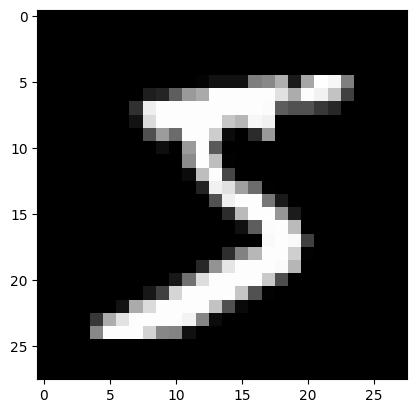

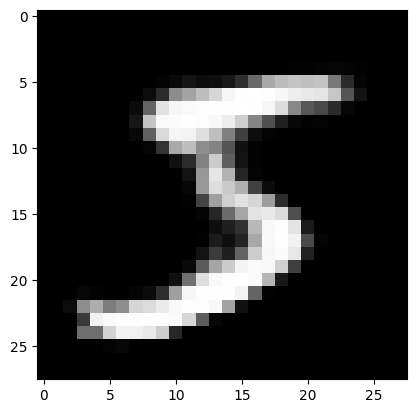

In [16]:
plt.imshow(np.reshape(x_train[0],(28,28)), cmap="gray")
plt.show()
plt.imshow(np.reshape(x_autoencoder[0],(28,28)), cmap="gray")
plt.show()

In [17]:
# encoder
x_code = encoder(x_train)

In [18]:
x_code.shape

TensorShape([60000, 32])

In [19]:
x_decode = decoder(x_code)

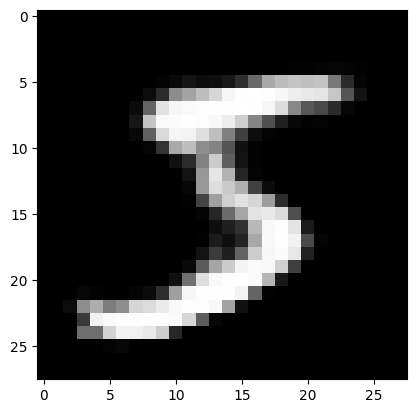

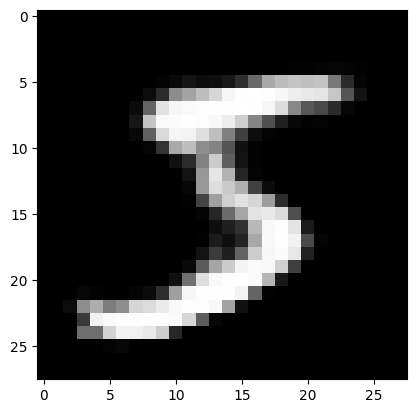

In [20]:
plt.imshow(np.reshape(x_decode[0],(28,28)), cmap="gray")
plt.show()
plt.imshow(np.reshape(x_autoencoder[0],(28,28)), cmap="gray")
plt.show()

In [22]:
x1 = x_decode[1] - x_autoencoder[1]
x2 = x_train[1] - x_autoencoder[1]

In [23]:
np.sum(x1)

np.float32(0.0)

In [24]:
np.sum(x2)

np.float32(-2.6100357)